In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os
import warnings
warnings.filterwarnings("ignore")

# Raw BLS data stays in Downloads — notebook is in the portfolio subfolder
BASE_PATH   = r"C:\Users\akash\Downloads"
CHARTS_PATH = r"C:\Users\akash\Downloads\TeamNEO_Research_Portfolio\01_BLS_Workforce_Analysis\charts"
os.makedirs(CHARTS_PATH, exist_ok=True)

YEARS = [2021, 2022, 2023, 2024]

# Cleveland MSA was renumbered by BLS: C1746 (2021-2023) → C1741 (2024)
CLEVELAND_PRIMARY   = "C1746 Cleveland-Elyria, OH MSA.csv"
CLEVELAND_FALLBACKS = ["C1741 Cleveland, OH MSA.csv"]
CSA_FALLBACK        = "CS184 Cleveland-Akron-Canton, OH CSA.csv"

OTHER_MSAS = [
    "C1042 Akron, OH MSA.csv",
    "C1594 Canton-Massillon, OH MSA.csv",
]

MSA_NAICS_AGGLVL = 44

INDUSTRY_NAMES = {
    "10": "Total, All Industries",
    "11": "Agriculture & Forestry",
    "21": "Mining & Oil",
    "22": "Utilities",
    "23": "Construction",
    "31-33": "Manufacturing",
    "42": "Wholesale Trade",
    "44-45": "Retail Trade",
    "48-49": "Transportation & Warehousing",
    "51": "Information",
    "52": "Finance & Insurance",
    "53": "Real Estate",
    "54": "Professional & Technical Services",
    "55": "Management",
    "56": "Administrative & Waste Services",
    "61": "Educational Services",
    "62": "Healthcare & Social Assistance",
    "71": "Arts & Entertainment",
    "72": "Accommodation & Food Services",
    "81": "Other Services",
    "92": "Public Administration",
}

# ── STEP 1: LOAD DATA ──────────────────────────────────
print("=" * 60)
print("   NEO BLS WORKFORCE ANALYSIS — Cleveland-Akron-Canton")
print("=" * 60)

all_data = []
year_source_log = {}
years_with_full_data = []

for year in YEARS:
    possible_folders = [
        os.path.join(BASE_PATH, f"{year}_annual_by_area", f"{year}.annual.by_area"),
        os.path.join(BASE_PATH, f"{year}.annual.by_area"),
    ]
    folder = next((f for f in possible_folders if os.path.isdir(f)), None)
    if folder is None:
        print(f"  [SKIP] {year}: data folder not found")
        continue

    sources = []
    year_frames = []

    clev_candidates = [CLEVELAND_PRIMARY] + CLEVELAND_FALLBACKS
    clev_loaded = False
    for candidate in clev_candidates:
        path = os.path.join(folder, f"{year}.annual {candidate}")
        if os.path.exists(path):
            df = pd.read_csv(path)
            df.columns = df.columns.str.strip()
            df["year"] = year
            year_frames.append(df)
            sources.append((candidate, "MSA"))
            clev_loaded = True
            break

    if not clev_loaded:
        csa_path = os.path.join(folder, f"{year}.annual {CSA_FALLBACK}")
        if os.path.exists(csa_path):
            df = pd.read_csv(csa_path)
            df.columns = df.columns.str.strip()
            df["year"] = year
            year_frames.append(df)
            sources.append((CSA_FALLBACK, "CSA-fallback"))
            print(f"  [WARN] {year}: Cleveland MSA missing — using CSA file instead")
        else:
            sources.append(("(none)", "MISSING"))
            print(f"  [WARN] {year}: Cleveland MSA AND CSA file both missing — Cleveland excluded")

    for msa in OTHER_MSAS:
        path = os.path.join(folder, f"{year}.annual {msa}")
        if os.path.exists(path):
            df = pd.read_csv(path)
            df.columns = df.columns.str.strip()
            df["year"] = year
            year_frames.append(df)
            sources.append((msa, "MSA"))
        else:
            sources.append((msa, "MISSING"))
            print(f"  [WARN] {year}: {msa} not found")

    if year_frames:
        all_data.extend(year_frames)
        years_with_full_data.append(year)

    year_source_log[year] = sources

assert all_data, "No data loaded at all. Check BASE_PATH."

data = pd.concat(all_data, ignore_index=True)

print()
print(f"{'Year':<6} {'File':<45} {'Type':<14} {'Status'}")
print("-" * 80)
for yr in YEARS:
    if yr not in year_source_log:
        print(f"  {yr}   (folder missing)")
        continue
    for fname, ftype in year_source_log[yr]:
        status = "OK" if ftype != "MISSING" else "MISSING"
        note   = " <-- renamed from C1746" if "C1741" in fname else ""
        note  += " <-- CSA used (no NAICS sector detail)" if ftype == "CSA-fallback" else ""
        print(f"  {yr}   {fname:<45} {ftype:<14} {status}{note}")

print()
print(f"  Total rows loaded : {len(data):,}")
print(f"  Years with data   : {years_with_full_data}")
print(f"  Charts will save to: {CHARTS_PATH}")
print("=" * 60)


   NEO BLS WORKFORCE ANALYSIS — Cleveland-Akron-Canton



Year   File                                          Type           Status
--------------------------------------------------------------------------------
  2021   C1746 Cleveland-Elyria, OH MSA.csv            MSA            OK
  2021   C1042 Akron, OH MSA.csv                       MSA            OK
  2021   C1594 Canton-Massillon, OH MSA.csv            MSA            OK
  2022   C1746 Cleveland-Elyria, OH MSA.csv            MSA            OK
  2022   C1042 Akron, OH MSA.csv                       MSA            OK
  2022   C1594 Canton-Massillon, OH MSA.csv            MSA            OK
  2023   C1746 Cleveland-Elyria, OH MSA.csv            MSA            OK
  2023   C1042 Akron, OH MSA.csv                       MSA            OK
  2023   C1594 Canton-Massillon, OH MSA.csv            MSA            OK
  2024   C1741 Cleveland, OH MSA.csv                   MSA            OK <-- renamed from C1746
  2024   C1042 Akron, OH MSA.csv                       MSA            OK
  2024   C1594 Ca

In [2]:
# ── STEP 2: FILTER & AGGREGATE ─────────────────────────
# agglvl_code 44 = MSA, NAICS Sector by ownership  (own_code 5 = private)
sector_data = data[
    (data["agglvl_code"] == MSA_NAICS_AGGLVL) &
    (data["own_code"] == 5)
].copy()

sector_data["industry_code"]      = sector_data["industry_code"].astype(str).str.strip()
sector_data["industry_name"]      = sector_data["industry_code"].map(INDUSTRY_NAMES).fillna("Other")
sector_data["annual_avg_emplvl"]  = pd.to_numeric(sector_data["annual_avg_emplvl"],  errors="coerce")
sector_data["annual_avg_wkly_wage"] = pd.to_numeric(sector_data["annual_avg_wkly_wage"], errors="coerce")

def weighted_wage(grp):
    total_emp = grp["annual_avg_emplvl"].sum()
    return 0 if total_emp == 0 else (grp["annual_avg_wkly_wage"] * grp["annual_avg_emplvl"]).sum() / total_emp

agg = (
    sector_data
    .groupby(["year", "industry_name", "industry_code"])
    .apply(lambda g: pd.Series({
        "annual_avg_emplvl":    g["annual_avg_emplvl"].sum(),
        "annual_avg_wkly_wage": weighted_wage(g),
    }))
    .reset_index()
)

print(f"Sector rows after aggregation : {len(agg)}")
print(f"Years present in agg          : {sorted(agg['year'].unique())}")
print(agg[["year","industry_name","annual_avg_emplvl","annual_avg_wkly_wage"]].head(10).to_string(index=False))


Sector rows after aggregation : 80
Years present in agg          : [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
 year                   industry_name  annual_avg_emplvl  annual_avg_wkly_wage
 2021   Accommodation & Food Services           114967.0            395.629589
 2021 Administrative & Waste Services            84986.0            828.292978
 2021          Agriculture & Forestry             3196.0            763.028160
 2021            Arts & Entertainment            19932.0           1002.489013
 2021                    Construction            57539.0           1302.051530
 2021            Educational Services            26574.0            862.690939
 2021             Finance & Insurance            64103.0           1957.462708
 2021  Healthcare & Social Assistance           208851.0           1126.055101
 2021                     Information            17626.0           1575.586577
 2021                      Management            40936.0           2428.402189

In [3]:
# ── STEP 3: ANALYSIS ───────────────────────────────────
latest_year = max(YEARS)
latest = agg[agg["year"] == latest_year].copy()
top10 = latest.nlargest(10, "annual_avg_emplvl")[["industry_name", "annual_avg_emplvl", "annual_avg_wkly_wage"]]

print(f"TOP 10 INDUSTRIES BY EMPLOYMENT ({latest_year}):")
print(f"{'Industry':<40} {'Avg Employment':>15} {'Avg Weekly Wage':>16}")
print("-" * 73)
for _, row in top10.iterrows():
    print(f"  {row['industry_name']:<38} {int(row['annual_avg_emplvl']):>15,} ${int(row['annual_avg_wkly_wage']):>14,}")

pivot = agg.pivot_table(
    index="industry_name", columns="year", values="annual_avg_emplvl", aggfunc="sum"
).dropna()
first_year = min(YEARS)
pivot["growth_pct"] = ((pivot[latest_year] - pivot[first_year]) / pivot[first_year] * 100).round(1)
pivot_sorted = pivot.sort_values("growth_pct", ascending=False)

print(f"\nINDUSTRY GROWTH: {first_year} to {latest_year}")
print(f"{'Industry':<40} {'Growth %':>10}")
print("-" * 52)
for industry, row in pivot_sorted.iterrows():
    arrow = "UP" if row["growth_pct"] > 0 else "DN"
    print(f"  {industry:<38} {arrow} {abs(row['growth_pct']):>6.1f}%")

TOP 10 INDUSTRIES BY EMPLOYMENT (2024):
Industry                                  Avg Employment  Avg Weekly Wage
-------------------------------------------------------------------------
  Healthcare & Social Assistance                 232,183 $         1,288
  Manufacturing                                  187,064 $         1,452
  Retail Trade                                   149,909 $           708
  Accommodation & Food Services                  130,976 $           458
  Administrative & Waste Services                 76,113 $           987
  Professional & Technical Services               72,910 $         1,898
  Construction                                    63,448 $         1,491
  Wholesale Trade                                 62,187 $         1,684
  Finance & Insurance                             59,861 $         2,209
  Other Services                                  45,264 $           858

INDUSTRY GROWTH: 2021 to 2024
Industry                                   Growth %

Chart 1 saved: C:\Users\akash\Downloads\TeamNEO_Research_Portfolio\01_BLS_Workforce_Analysis\charts\neo_chart1_top_industries.png


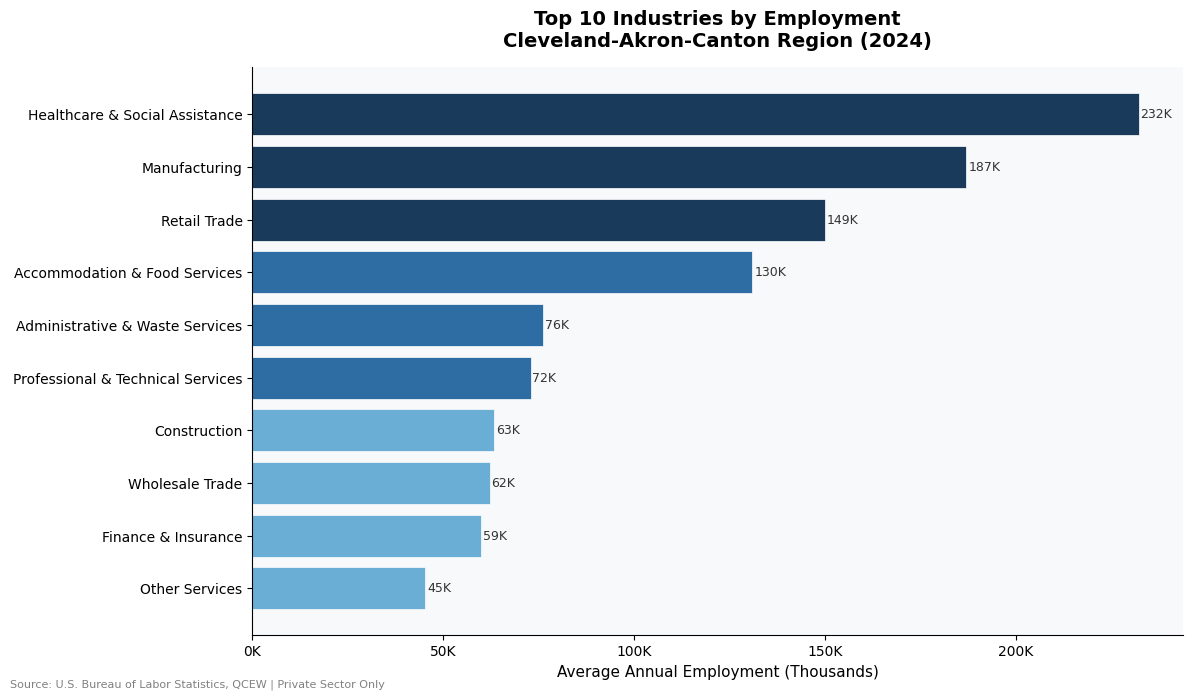

In [4]:
# ── CHART 1: Top 10 Industries Bar Chart ───────────────
colors = ["#1a3a5c" if i < 3 else "#2e6da4" if i < 6 else "#6aaed6" for i in range(10)]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(
    top10["industry_name"][::-1],
    top10["annual_avg_emplvl"][::-1] / 1000,
    color=colors[::-1], edgecolor="white", linewidth=0.5
)
for bar, val in zip(bars, top10["annual_avg_emplvl"][::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{int(val/1000)}K", va="center", fontsize=9, color="#333333")

ax.set_xlabel("Average Annual Employment (Thousands)", fontsize=11)
ax.set_title(f"Top 10 Industries by Employment\nCleveland-Akron-Canton Region ({latest_year})",
             fontsize=14, fontweight="bold", pad=15)
ax.set_facecolor("#f8f9fa")
fig.patch.set_facecolor("white")
ax.spines[["top", "right"]].set_visible(False)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x)}K"))
fig.text(0.01, 0.01, "Source: U.S. Bureau of Labor Statistics, QCEW | Private Sector Only",
         fontsize=8, color="gray")
plt.tight_layout()
chart1_path = os.path.join(CHARTS_PATH, "neo_chart1_top_industries.png")
plt.savefig(chart1_path, dpi=150, bbox_inches="tight")
print(f"Chart 1 saved: {chart1_path}")
plt.show()


Chart 2 saved: C:\Users\akash\Downloads\TeamNEO_Research_Portfolio\01_BLS_Workforce_Analysis\charts\neo_chart2_employment_trend.png  (years: [2021, 2022, 2023, 2024])


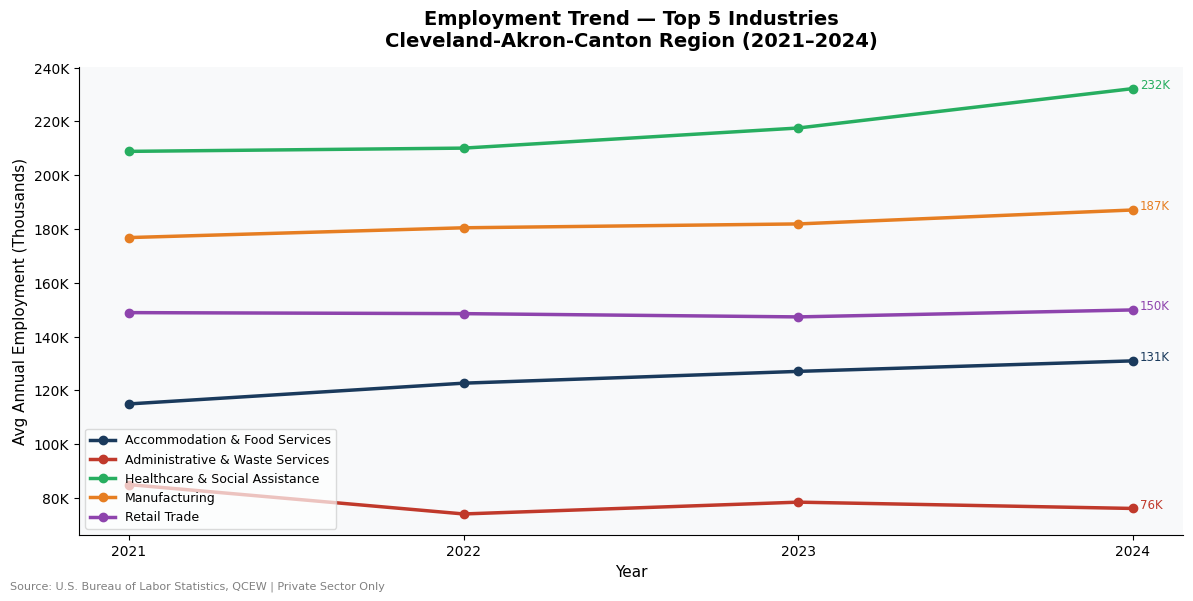

In [5]:
# ── CHART 2: Employment Trend (Top 5) ──────────────────
top5_industries = top10["industry_name"].head(5).tolist()
trend_data  = agg[agg["industry_name"].isin(top5_industries)]
trend_pivot = trend_data.pivot_table(
    index="year", columns="industry_name", values="annual_avg_emplvl", aggfunc="sum"
) / 1000

trend_years = sorted(trend_pivot.index.tolist())
year_range  = f"{trend_years[0]}–{trend_years[-1]}" if len(trend_years) > 1 else str(trend_years[0])

line_colors = ["#1a3a5c", "#c0392b", "#27ae60", "#e67e22", "#8e44ad"]

fig, ax = plt.subplots(figsize=(12, 6))
for i, col in enumerate(trend_pivot.columns):
    ax.plot(trend_pivot.index, trend_pivot[col],
            marker="o", linewidth=2.5, color=line_colors[i % len(line_colors)],
            label=col, markersize=6)
    ax.annotate(f"{trend_pivot[col].iloc[-1]:.0f}K",
                xy=(trend_pivot.index[-1], trend_pivot[col].iloc[-1]),
                xytext=(5, 0), textcoords="offset points",
                fontsize=8.5, color=line_colors[i % len(line_colors)])

ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Avg Annual Employment (Thousands)", fontsize=11)
ax.set_title(f"Employment Trend — Top 5 Industries\nCleveland-Akron-Canton Region ({year_range})",
             fontsize=14, fontweight="bold", pad=15)
ax.legend(loc="lower left", fontsize=9, framealpha=0.7)
ax.set_facecolor("#f8f9fa")
fig.patch.set_facecolor("white")
ax.spines[["top", "right"]].set_visible(False)
ax.set_xticks(trend_years)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x)}K"))

footnote = "Source: U.S. Bureau of Labor Statistics, QCEW | Private Sector Only"
if set(trend_years) != set(YEARS):
    missing = sorted(set(YEARS) - set(trend_years))
    footnote += f" | Note: {missing} excluded (data unavailable)"
fig.text(0.01, 0.01, footnote, fontsize=8, color="gray")

plt.tight_layout()
chart2_path = os.path.join(CHARTS_PATH, "neo_chart2_employment_trend.png")
plt.savefig(chart2_path, dpi=150, bbox_inches="tight")
print(f"Chart 2 saved: {chart2_path}  (years: {trend_years})")
plt.show()


Chart 3 saved: C:\Users\akash\Downloads\TeamNEO_Research_Portfolio\01_BLS_Workforce_Analysis\charts\neo_chart3_wages.png


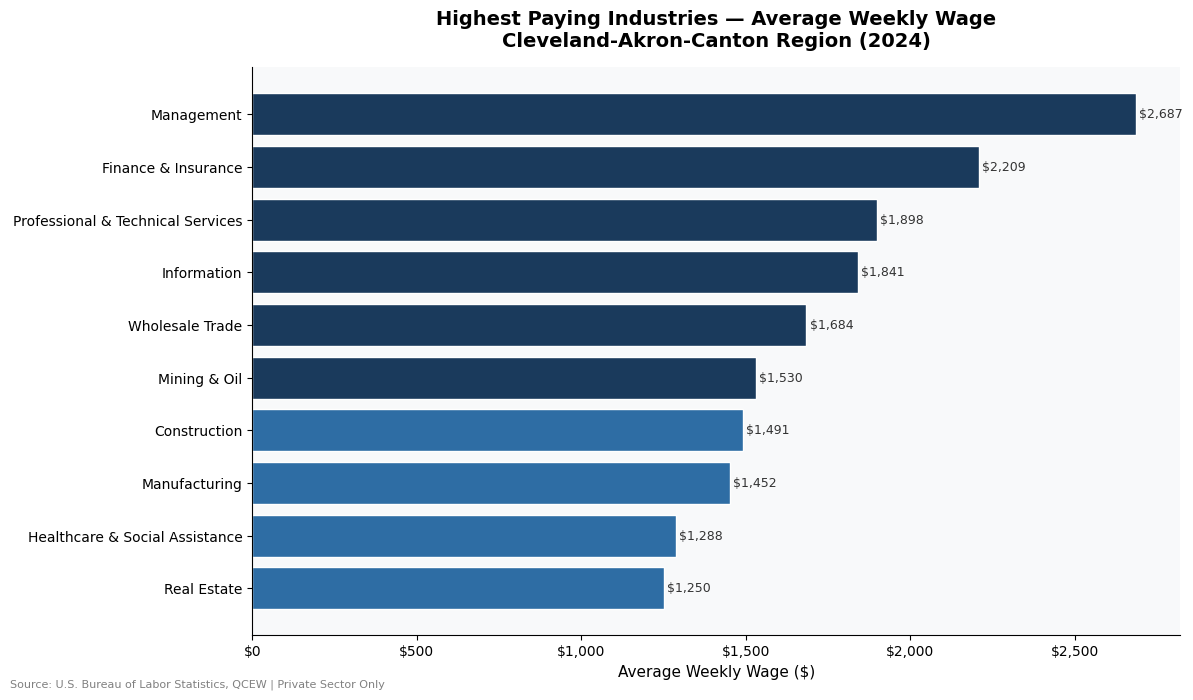


  ALL DONE!
  Charts saved to: C:\Users\akash\Downloads\TeamNEO_Research_Portfolio\01_BLS_Workforce_Analysis\charts


In [6]:
# ── CHART 3: Average Weekly Wage ───────────────────────
wage_data = latest.nlargest(10, "annual_avg_wkly_wage")[["industry_name", "annual_avg_wkly_wage"]]
wage_colors = ["#1a3a5c" if w > 1500 else "#2e6da4" if w > 1000 else "#6aaed6"
               for w in wage_data["annual_avg_wkly_wage"]]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(
    wage_data["industry_name"][::-1],
    wage_data["annual_avg_wkly_wage"][::-1],
    color=wage_colors[::-1], edgecolor="white"
)
for bar, val in zip(bars, wage_data["annual_avg_wkly_wage"][::-1]):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height() / 2,
            f"${int(val):,}", va="center", fontsize=9, color="#333333")

ax.set_xlabel("Average Weekly Wage ($)", fontsize=11)
ax.set_title(f"Highest Paying Industries — Average Weekly Wage\nCleveland-Akron-Canton Region ({latest_year})",
             fontsize=14, fontweight="bold", pad=15)
ax.set_facecolor("#f8f9fa")
fig.patch.set_facecolor("white")
ax.spines[["top", "right"]].set_visible(False)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${int(x):,}"))
fig.text(0.01, 0.01, "Source: U.S. Bureau of Labor Statistics, QCEW | Private Sector Only",
         fontsize=8, color="gray")
plt.tight_layout()
chart3_path = os.path.join(CHARTS_PATH, "neo_chart3_wages.png")
plt.savefig(chart3_path, dpi=150, bbox_inches="tight")
print(f"Chart 3 saved: {chart3_path}")
plt.show()

print("\n" + "=" * 60)
print("  ALL DONE!")
print(f"  Charts saved to: {CHARTS_PATH}")
print("=" * 60)
